STEP 0: Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

STEP 1: Read the file from google colab

1.1 Read the original data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Path to the provided CSV file
import pandas as pd
file_path = '/content/drive/My Drive/BUS 450 Vinfast/Data/Vinfast.csv'

# Load the CSV file
df = pd.read_csv(file_path)
df.head(3)

,Unnamed: 0,Comment Text,Published At_x,Updated At,Like Count,Reply Count,Is Reply,Reply To,Author Name,Author Channel ID,...,Channel Title,Views,Likes,Comments,Duration,Definition,Caption Available,Privacy Status,Video Link,Subscribers
0,0,"What do you guys think of the VinFast VF 8? Also, do you want to see more car reviews on the channel or keep it separate on @worththewatt ?",2024-11-14T14:27:35Z,2024-11-14T14:27:35Z,17.0,3.0,False,NaN,@MatthewMoniz,UCVlMUh4WsDQvOxCJJXmWwdw,...,Matthew Moniz,14952,377,76,PT12M38S,hd,False,public,https://www.youtube.com/watch?v=jrstnv1iyyA,820000
1,1,Definitely enjoy my 24 ECO. I went with the ECO for more headroom and range. The plus is fantastic though; almost got it instead. Test drove both.,2024-11-15T08:07:42Z,2024-11-15T08:07:42Z,4.0,0.0,True,@MatthewMoniz,@capiquedotcom,UC0WaY6WX5hAWb6LJTl-siiw,...,Matthew Moniz,14952,377,76,PT12M38S,hd,False,public,https://www.youtube.com/watch?v=jrstnv1iyyA,820000
2,2,"Please keep it separate, it dilutes the purpose.",2024-11-16T05:10:44Z,2024-11-16T05:10:44Z,0.0,0.0,True,@MatthewMoniz,@titasdas8615,UCY4MEx28g0SrZoOeXFV18Hw,...,Matthew Moniz,14952,377,76,PT12M38S,hd,False,public,https://www.youtube.com/watch?v=jrstnv1iyyA,820000


1.2 Read the Vietnamse data with sentiment

In [ ]:
# Path to the provided CSV file
import pandas as pd
file_path_2 = '/content/drive/My Drive/BUS 450 Vinfast/Data/vietnamese_comments_with_sentiment.csv'

# Load the CSV file
df2 = pd.read_csv(file_path_2)
df2.head(3)

,Unnamed: 0,Comment Text,Published At_x,Updated At,Like Count,Reply Count,Is Reply,Reply To,Author Name,Author Channel ID,...,Likes,Comments,Duration,Definition,Caption Available,Privacy Status,Video Link,Subscribers,Language,predicted_sentiment
0,4,"Chiếc xe này giống như là chiếc điện thoại bạn vừa mới mua về một khi bạn đi nó thì rất muốn tìm hiểu, và bạn sẽ rất thích 100%",2024-11-17T06:12:53Z,2024-11-17T06:12:53Z,0.0,0.0,False,NaN,@huybui5378,UC9qkYETLQim_DXHrzYVZCFQ,...,377,76,PT12M38S,hd,False,public,https://www.youtube.com/watch?v=jrstnv1iyyA,820000,vi,Neutral
1,17,Tôi đang sở hữu Vinfast rất hài lòng về nó 👍❤,2024-11-15T13:07:10Z,2024-11-15T13:07:10Z,0.0,0.0,False,NaN,@nguyenvanhung9542,UC_shKLZDTRpNOwz_6RbAGEA,...,377,76,PT12M38S,hd,False,public,https://www.youtube.com/watch?v=jrstnv1iyyA,820000,vi,Neutral
2,19,Vf8 ❤❤❤ thật sự đẹp và tôi thích nó,2024-11-15T12:43:45Z,2024-11-15T12:43:45Z,0.0,0.0,False,NaN,@dungduc4047,UCSqra6BE7igSTaPTUXoxvQQ,...,377,76,PT12M38S,hd,False,public,https://www.youtube.com/watch?v=jrstnv1iyyA,820000,vi,Neutral


In [ ]:
df2.shape

(20287, 32)

In [ ]:
df2.columns

Index(['Unnamed: 0', 'Comment Text', 'Published At_x', 'Updated At',
       'Like Count', 'Reply Count', 'Is Reply', 'Reply To', 'Author Name',
       'Author Channel ID', 'Author Channel URL', 'Author Profile Image URL',
       'Author Is Channel Owner', 'Video URL', 'Query', 'Video ID', 'Title',
       'Description', 'Published At_y', 'Tags', 'Channel Title', 'Views',
       'Likes', 'Comments', 'Duration', 'Definition', 'Caption Available',
       'Privacy Status', 'Video Link', 'Subscribers', 'Language',
       'predicted_sentiment'],
      dtype='object')

Overall the result of sentiment would be more suitable since nowsaday people tend to have the negative opinion

In [ ]:
df2['predicted_sentiment'].value_counts()

,count
predicted_sentiment,
Neutral,10550
Negative,8875
Positive,862


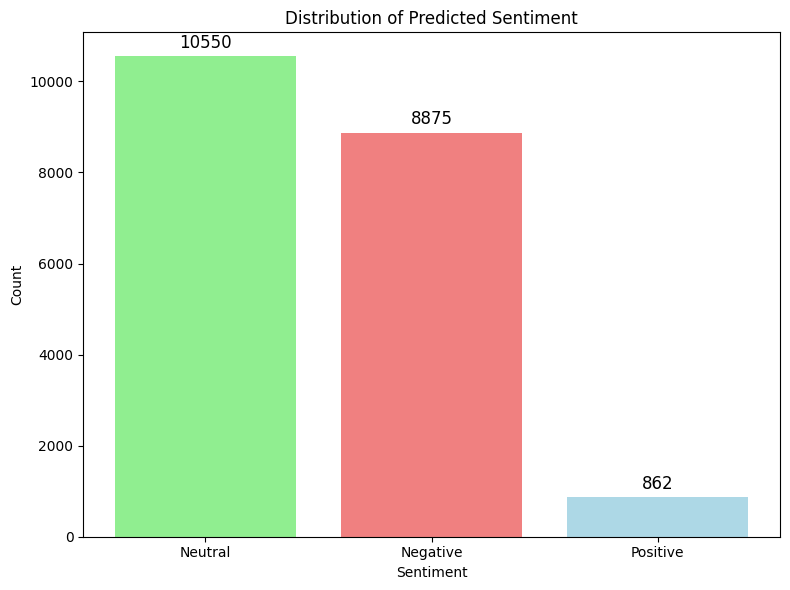

In [ ]:
# Assuming you have the df DataFrame already loaded and it contains the 'predicted_sentiment' column

# Get the value counts for 'predicted_sentiment'
sentiment_counts = df2['predicted_sentiment'].value_counts()

# Plotting the bar chart with different colors for each bar
colors = ['lightgreen', 'lightcoral', 'lightblue']

plt.figure(figsize=(8, 6))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors)

# Adding title and labels
plt.title('Distribution of Predicted Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Count')

# Display the number of counts on top of the bars
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 100, str(v), ha='center', va='bottom', fontsize=12)

# Rotate x-axis labels horizontally
plt.xticks(rotation=0)

# Show the plot
plt.tight_layout()
plt.show()


STEP 3: Creating Perplexity Chart

3.1 POSITIVE COMMENTS

In [ ]:
# Import necessary libraries
import pandas as pd
import re
#from pyvi import ViTokenizer
from gensim import corpora
from gensim.models import Phrases
from gensim.models.phrases import Phraser

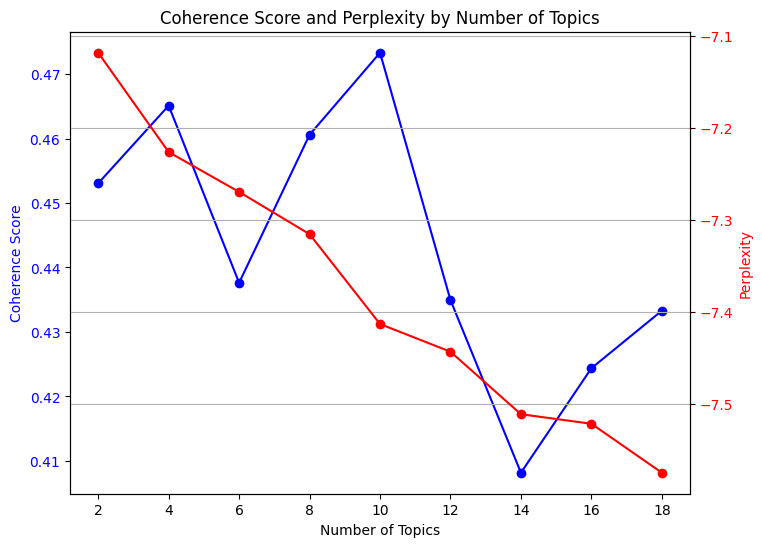

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# Load the dataset
#file_path = "/mnt/data/vietnamese_comments_with_sentiment (1).csv"
#df = pd.read_csv(file_path)

# 1️⃣ Lọc bình luận có sentiment "Positive"
positive_comments = df2[df2['predicted_sentiment'] == 'Positive']['Comment Text'].dropna().tolist()

# 2️⃣ Tiền xử lý dữ liệu
def preprocess_text(text):
    """
    Tiền xử lý văn bản:
    - Chuyển về chữ thường
    - Loại bỏ URL và ký tự đặc biệt
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # Loại bỏ URL
    text = re.sub(r"[^a-zA-ZÀ-Ỹà-ỹ\s]", "", text)  # Loại bỏ ký tự đặc biệt
    return text.split()  # Tách thành danh sách các từ

# Áp dụng tiền xử lý
processed_positive_comments = [preprocess_text(comment) for comment in positive_comments]

# 3️⃣ Tạo Dictionary và Corpus cho mô hình LDA
dictionary = corpora.Dictionary(processed_positive_comments)
corpus = [dictionary.doc2bow(text) for text in processed_positive_comments]

# 4️⃣ Chạy LDA với nhiều số lượng chủ đề và tính Perplexity & Coherence Score
topic_numbers = list(range(2, 20, 2))  # Số lượng chủ đề từ 2 đến 18
perplexity_values = []
coherence_scores = []

for num_topics in topic_numbers:
    lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=42)

    # Tính Perplexity
    perplexity = lda_model.log_perplexity(corpus)
    perplexity_values.append(perplexity)

    # Tính Coherence Score
    coherence_model = CoherenceModel(model=lda_model, texts=processed_positive_comments, dictionary=dictionary, coherence="c_v")
    coherence_score = coherence_model.get_coherence()
    coherence_scores.append(coherence_score)

# 5️⃣ Vẽ biểu đồ Perplexity và Coherence Score
fig, ax1 = plt.subplots(figsize=(8, 6))

# Vẽ Coherence Score (trục trái, màu xanh)
ax1.set_xlabel("Number of Topics")
ax1.set_ylabel("Coherence Score", color="blue")
ax1.plot(topic_numbers, coherence_scores, marker='o', linestyle='-', color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Tạo trục thứ hai để vẽ Perplexity (trục phải, màu đỏ)
ax2 = ax1.twinx()
ax2.set_ylabel("Perplexity", color="red")
ax2.plot(topic_numbers, perplexity_values, marker='o', linestyle='-', color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Tiêu đề biểu đồ
plt.title("Coherence Score and Perplexity by Number of Topics")
plt.grid(True)
plt.show()


3.2 : NEGATIVE COMMENTS

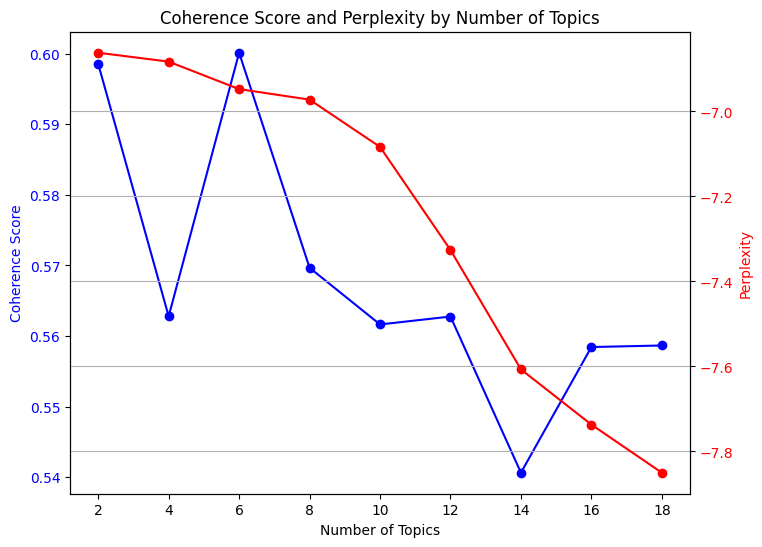

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# Load the dataset
#file_path = "/mnt/data/vietnamese_comments_with_sentiment (1).csv"
#df = pd.read_csv(file_path)

# 1️⃣ Lọc bình luận có sentiment "Negative"
negative_comments = df2[df2['predicted_sentiment'] == 'Negative']['Comment Text'].dropna().tolist()

# 2️⃣ Tiền xử lý dữ liệu
def preprocess_text(text):
    """
    Tiền xử lý văn bản:
    - Chuyển về chữ thường
    - Loại bỏ URL và ký tự đặc biệt
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # Loại bỏ URL
    text = re.sub(r"[^a-zA-ZÀ-Ỹà-ỹ\s]", "", text)  # Loại bỏ ký tự đặc biệt
    return text.split()  # Tách thành danh sách các từ

# Áp dụng tiền xử lý
processed_negative_comments = [preprocess_text(comment) for comment in negative_comments]

# 3️⃣ Tạo Dictionary và Corpus cho mô hình LDA
dictionary = corpora.Dictionary(processed_negative_comments)
corpus = [dictionary.doc2bow(text) for text in processed_negative_comments]

# 4️⃣ Chạy LDA với nhiều số lượng chủ đề và tính Perplexity & Coherence Score
topic_numbers = list(range(2, 20, 2))  # Số lượng chủ đề từ 2 đến 18
perplexity_values = []
coherence_scores = []

for num_topics in topic_numbers:
    lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=42)

    # Tính Perplexity
    perplexity = lda_model.log_perplexity(corpus)
    perplexity_values.append(perplexity)

    # Tính Coherence Score
    coherence_model = CoherenceModel(model=lda_model, texts=processed_negative_comments, dictionary=dictionary, coherence="c_v")
    coherence_score = coherence_model.get_coherence()
    coherence_scores.append(coherence_score)

# 5️⃣ Vẽ biểu đồ Perplexity và Coherence Score
fig, ax1 = plt.subplots(figsize=(8, 6))

# Vẽ Coherence Score (trục trái, màu xanh)
ax1.set_xlabel("Number of Topics")
ax1.set_ylabel("Coherence Score", color="blue")
ax1.plot(topic_numbers, coherence_scores, marker='o', linestyle='-', color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Tạo trục thứ hai để vẽ Perplexity (trục phải, màu đỏ)
ax2 = ax1.twinx()
ax2.set_ylabel("Perplexity", color="red")
ax2.plot(topic_numbers, perplexity_values, marker='o', linestyle='-', color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Tiêu đề biểu đồ
plt.title("Coherence Score and Perplexity by Number of Topics")
plt.grid(True)
plt.show()


STEP 4: PREPROCESSING

In [ ]:
!pip install pyvi
import pandas as pd
import re
from pyvi import ViTokenizer
from nltk.corpus import stopwords

In [ ]:
# Tải stopwords mặc định và bổ sung thêm stopwords tùy chỉnh
vietnamese_stop_words = set(["và", "là", "có", "của", "cho", "được", "những", "phút", "này"])
additional_stop_words = [
    'và', 'là', 'có', 'của', 'cho', 'được', 'những', 'phút', 'này', 'rằng',
    'một', 'cái', 'để', 'nên', 'thì', 'đã', 'tôi', 'bạn', 'chúng', 'thanhthuyang9697',
    'lol', 'liệu', 'khangnguyenqg3nm', 'dzồi', 'nhé', 'minhnguyenbz2pdchẳng', 'hồcm',
    'chetek5', 'douma', 'giveuup3709', 'sủa', 'con', 'thât', 'không', 'con', 'thi',
    'người', 'ngươi', 'đây', 'ban', "qua", "diễn", "anh", "cao", "nhất", "chi", "cần",
    "rồi", "phải", "nói", "chữ", "hay", "làm", "biết", "đâu", "như", "cũng", "nhưng",
    "pin", "tiền", "điện", "năm", "bán", "chỉ", "hơn", "thật", "vậy", "mày", "cầu",
    "hàng", "bao", "chế", "cung", "mình", "voi", "dung", "khách", "nhân", "thể", "tình",
    "thay", "chủ", "thang", "nao", "phần", "đúng", "nghe", "khúc", "chúng_tôi", "ngu",
    "mẫu", "tên", "trường", "thế", "hết", "chắc", "chạy", "video", "nhật", "việt",
    "nam", "bắc", "luôn", "nhiều", "còn", "nếu", "review", "bác", "thôi", "khi", "với",
    "trong", "nào", "chú", "chè", "lại", "quá", "sao", "nay", "dân", "ông", "mấy",
    "chưa", "rất", "trên", "theo", "cực", "lên", "vẫn", "thấy", "đến", "phần", "nữa",
    "xem", "hiểu", "moi", "xong", "nha", "kêu", "kiếm", "thực", "chè", "bọn", "khác",
    "sai", "xin", "noi", "chả", "nhanh", "vái", "người_ta", "đầu", "sau", "càng",
    "mắt", "chung", "nhau", "dang", "dong", "tập", "nhìn", "lấy", "tính", "bên",'mày','thic',
    "mới", "diện", "tiền", "st", "cua", "cai", "tập", "thế", "lại", "chức", "làm",'no',
    "chè", "điều", "chịu", "bát", "trà", "sàn", "hiệu", "dòng", "cùng", "trạm", "vùng",'ng','co',
    "hoặc", "cảm_ơn", "coi", "bằng", "toàn", "lần", "minh",'gái','ơi','kkk','baojun','kkk',
    'https','câ','la','ko','ng','youtu','be','ngươ','https','you','welcome'
]
stop_words = vietnamese_stop_words.union(additional_stop_words)

# Từ quan trọng cần giữ lại
terms_to_keep = {'vn'}

def preprocess_comment(comment):
    """
    Tiền xử lý văn bản:
    - Chuyển thành chữ thường.
    - Loại bỏ URL, ký tự đặc biệt, và tên người dùng.
    - Tokenize văn bản bằng ViTokenizer.
    - Loại bỏ stopwords nhưng giữ lại các từ quan trọng.
    """
    try:
        # Xử lý giá trị thiếu
        if pd.isna(comment):
            return ''
        # Chuyển văn bản thành chữ thường
        comment = comment.lower()
        # Loại bỏ URL
        comment = re.sub(r'http\S+|www\S+|https\S+', '', comment)
        # Loại bỏ tên người dùng (ví dụ: @username)
        comment = re.sub(r'@[\w\d_]+', '', comment)
        # Loại bỏ ký tự đặc biệt
        comment = re.sub(r'[^\w\s]', '', comment)

        # Tokenize với ViTokenizer
        comment = ViTokenizer.tokenize(comment)
        # Loại bỏ stopwords
        words = [word for word in comment.split() if (word not in stop_words or word in terms_to_keep) and len(word) > 2]
        return ' '.join(words)
    except Exception as e:
        print(f"Error processing comment: {comment}, error: {e}")
        return ''

# Áp dụng tiền xử lý lên cột dữ liệu
df2['processed_comment'] = df2['Comment Text'].fillna("").apply(preprocess_comment)

# Tạo danh sách các văn bản đã tiền xử lý
docs = df2['processed_comment'].tolist()

print(f"Processed {len(docs)} comments ready for BERTopic.")


Processed 20287 comments ready for BERTopic.


STEP 5: BERT TOPIC

In [ ]:
!pip install bertopic
# Install BERTopic with visualization support
!pip install bertopic[visualization] --quiet
import numpy as np
import pandas as pd
from copy import deepcopy
from bertopic import BERTopic

In [ ]:
# Install BERTopic
#!pip install bertopic --quiet

# Install visualization dependencies separately
##!pip install matplotlib seaborn plotly umap-learn hdbscan --quiet

# Import necessary libraries
#import numpy as np
#import pandas as pd
#from bertopic import BERTopic


https://maartengr.github.io/BERTopic/index.html?zarsrc=30&utm_source=zalo&utm_medium=zalo&utm_campaign=zalo#visualizations

5.1 POSITIVE COMMENTS

In [ ]:
positive_comments = df2[df2['predicted_sentiment'] == 'Positive']['Comment Text']

# Chuyển đổi thành danh sách để sử dụng trong BERTopic
docs = positive_comments.tolist()

# Khởi tạo mô hình BERTopic cho tiếng Việt
topic_model = BERTopic(language="vietnamese")

# Huấn luyện mô hình BERTopic trên các bình luận tích cực
topics, probs = topic_model.fit_transform(docs)

#7.3 Extract most frequent topics
# Xem tần suất chủ đề
print("Topic Frequencies:")
print(topic_model.get_topic_freq())

Topic Frequencies:
   Topic  Count
0      0    821
1      1     32
2     -1      9


(862,)

In [ ]:
# Hiển thị tần suất chủ đề dưới dạng DataFrame
topic_freq = topic_model.get_topic_freq()
print(topic_freq.head(11))  # Hiển thị 10 topic phổ biến nhất


   Topic  Count
0      0    821
1      1     32
2     -1      9


5.2 Get individual topics

In [ ]:
topic_model.get_topic(-1)

[('dong', 0.11526891106223648),
 ('nguoi', 0.09479824416289896),
 ('vinfas', 0.09479824416289896),
 ('chan', 0.09479824416289896),
 ('chay', 0.08864679209393761),
 ('khong', 0.08864679209393761),
 ('chạm', 0.08864679209393761),
 ('xe', 0.0882018905904599),
 ('con', 0.08506266782205289),
 ('ma', 0.0776121561730584)]

In [ ]:
topic_model.get_topic(1)

[('việt', 0.13664285910828908),
 ('nam', 0.1153799410638195),
 ('và', 0.06380365618204797),
 ('người', 0.05663513040989648),
 ('xe', 0.051970523465046714),
 ('của', 0.049614941838852025),
 ('là', 0.046400177468730874),
 ('vinfast', 0.046323489147579),
 ('cảm', 0.04287663016336184),
 ('có', 0.04237022291490216)]

In [ ]:
topic_model.get_topic(2)

False

In [ ]:
topic_model.get_topic(3)

False

In [ ]:
topic_model.get_topic(4)

False

In [ ]:
topic_model.get_topic(5)

False

In [ ]:
topic_model.get_topic(6)

False

In [ ]:
topic_model.get_topic(7)

False

In [ ]:
topic_model.get_topic(8)

False

In [ ]:
topic_model.get_topic(9)

False

5.3 Visualize Topic

In [ ]:
topic_model.visualize_topics()

ValueError: zero-size array to reduction operation maximum which has no identity

STEP 6: BERT TOPIC FOR NEGATIVE

In [ ]:
negative_comments = df2[df2['predicted_sentiment'] == 'Negative']['Comment Text']

# Chuyển đổi thành danh sách để sử dụng trong BERTopic
docs_2 = negative_comments.tolist()

# Khởi tạo mô hình BERTopic cho tiếng Việt
topic_model = BERTopic(language="vietnamese")

# Huấn luyện mô hình BERTopic trên các bình luận tiêu cực
topics, probs = topic_model.fit_transform(docs_2)

#7.3 Extract most frequent topics
# Xem tần suất chủ đề
print("Topic Frequencies:")
print(topic_model.get_topic_freq())

Topic Frequencies:
     Topic  Count
3       -1   3664
9        0    455
41       1    268
4        2    154
68       3    128
..     ...    ...
107    112     10
16     113     10
103    114     10
83     115     10
38     116     10

[118 rows x 2 columns]


In [ ]:
# Hiển thị tần suất chủ đề dưới dạng DataFrame
topic_freq = topic_model.get_topic_freq()
print(topic_freq.head(7))  # Hiển thị 10 topic phổ biến nhất


    Topic  Count
3      -1   3664
9       0    455
41      1    268
4       2    154
68      3    128
26      4    127
23      5    119


6.2 Get individual topics

In [ ]:
topic_model.get_topic(-1)

[('xe', 0.007639243671832836),
 ('có', 0.006868567524182893),
 ('là', 0.00684930111857201),
 ('thì', 0.0068104496124211855),
 ('đi', 0.006520121129382102),
 ('hơn', 0.005926163106307453),
 ('mà', 0.005882482021038403),
 ('mua', 0.005878025119282042),
 ('như', 0.005827673955057222),
 ('không', 0.005749852760242831)]

In [ ]:
topic_model.get_topic(0)

[('xấu', 0.012795594246632465),
 ('tay', 0.011355594590570756),
 ('cái', 0.010925945313602144),
 ('không', 0.01081927093263967),
 ('thằng', 0.01045376871726347),
 ('nói', 0.00982605456765285),
 ('chưa', 0.009410536274534953),
 ('đâu', 0.009225850362066856),
 ('đúng', 0.009188683188139212),
 ('nghe', 0.008940294737313932)]

In [ ]:
topic_model.get_topic(1)

[('điện', 0.0398032892016589),
 ('xe', 0.017507695698638148),
 ('xăng', 0.01736534539756357),
 ('thì', 0.009470029393312918),
 ('hơn', 0.008846634513780515),
 ('nhiều', 0.007923663678855221),
 ('là', 0.007773143447246533),
 ('cũng', 0.007191947360855872),
 ('với', 0.007165418314865526),
 ('nó', 0.0068881745615402765)]

In [ ]:
topic_model.get_topic(2)

[('việt', 0.0858649351036272),
 ('nam', 0.08191542708486962),
 ('from', 0.023475920853778396),
 ('người', 0.021721133884856986),
 ('vietnam', 0.021343597000177024),
 ('you', 0.015867592093733607),
 ('bạn', 0.015306581722830186),
 ('tôi', 0.014708996413979046),
 ('cộng', 0.013771174519619582),
 ('anh', 0.013325466895081448)]

In [ ]:
topic_model.get_topic(3)

[('pin', 0.07689384615406342),
 ('thuê', 0.0387185575235688),
 ('thay', 0.01916946490114735),
 ('mua', 0.01645064574938885),
 ('cục', 0.01435282774269479),
 ('cả', 0.01426591566778941),
 ('đứt', 0.01400492765294504),
 ('giá', 0.012967801328916869),
 ('bánh', 0.012633957088019414),
 ('lăn', 0.012472803029308603)]

In [ ]:
topic_model.get_topic(4)

[('nguyenhiep2708', 0.01882327372800323),
 ('anh', 0.016032202358144863),
 ('biết', 0.014873776388882026),
 ('nhé', 0.013979094797325967),
 ('nguyển', 0.013391885984759575),
 ('thịu', 0.013391885984759575),
 ('ominhphuong7879', 0.013391885984759575),
 ('hotline', 0.013391885984759575),
 ('nhatchattin5531', 0.013391885984759575),
 ('thaisonvi9904', 0.013391885984759575)]

In [ ]:
topic_model.get_topic(5)

[('km', 0.03141604523181739),
 ('tốc', 0.021022623924273898),
 ('đi', 0.020653223249050078),
 ('300km', 0.01890602944915312),
 ('chạy', 0.018786114024641372),
 ('sạc', 0.01741581000926793),
 ('bình', 0.01698170413864319),
 ('tháng', 0.016864944747384016),
 ('nghỉ', 0.015984409604422024),
 ('100km', 0.015409277207025302)]

6.3 Visualize topic

In [ ]:
topic_model.visualize_topics()

STEP 7: Check comments

In [ ]:
import re
pd.set_option('display.max_colwidth', None)
def find_rows_with_words(dataframe, column, words, condition='and'):
    regex_patterns = [rf'\b{re.escape(word)}\b' for word in words]

    if condition == 'and':
        mask = dataframe[column].apply(lambda text: all(re.search(pattern, text, re.IGNORECASE) for pattern in regex_patterns))
    elif condition == 'or':
        mask = dataframe[column].apply(lambda text: any(re.search(pattern, text, re.IGNORECASE) for pattern in regex_patterns))
    else:
        raise ValueError("Condition must be either 'and' or 'or'")

    return dataframe[mask]
                                                    #change the list of word
find=find_rows_with_words(df2,'Comment Text',['kính'], condition='or') #can change the condition to 'or'
find[['Comment Text','processed_comment','predicted_sentiment']].head(30)

,Comment Text,processed_comment,predicted_sentiment
170,Nắng hoặc ánh sáng chiếu vào mặt hiện lên mấy cái bóng từ kính nhìn hơi ghê =)),nắng ánh_sáng chiếu vào mặt hiện bóng kính hơi ghê,Neutral
304,Kính mong Các cơ quan chức năng vào cuộc kẻo hàng ngàn người sẽ chết oan vì loại ô tô hàng mã này của Vượng,kính mong các cơ_quan_chức_năng vào_cuộc kẻo ngàn chết oan loại ô_tô hàng_mã vượng,Negative
2326,Mình nghĩ về thiết kế bên ngoài thì OK rồi. Nhưng nếu mình mua thì nhất định phải thay kính chỉnh điện là cần thiết nhất. Sau đó thì muốn đẹp hơn thì độ mâm là được.,nghĩ thiết_kế ngoài mua nhất_định kính chỉnh cần_thiết muốn đẹp mâm,Neutral
2395,Xe đi đô thị mà.nên là xdinh mua con này chỉ đi loanh quanh phố bán kính 50km quay đầu.,đô_thị mànên xdinh mua loanh_quanh phố bán_kính 50km quay,Neutral
2434,Tiền ít đòi hít đồ ngon.xe này để đi chợ đón con.đi làm trong bán kính 20km thôi,đòi hít ngonxe chợ đón conđi bán_kính 20km,Neutral
2671,"Xe này đi lòng vòng trong phố, bán kính tầm 40km đổ lại thôi. Chứ xe mini 3 cửa chật chội, độ ổn định thân xe kém, pin sạc thì ko lưu trữ được nhiều. Là tôi thì tôi thà mua con Toyota Raize cho nhanh.",lòng_vòng phố bán_kính tầm 40km chứ mini cửa chật_chội ổn_định thân kém sạc lưu_trữ thà mua toyota raize,Neutral
3158,người VIỆT rất ngộ. muốn xe giá rẻ lại muốn đủ đồ chơi. lòng người khó chiều\ntôi có xe tôi chỉ có nhu cầu như sau\n1 lên sáng bộ đèn\n2 dán kính\n3 lót sàn\n4 mua cặp gương điện.xong,ngộ muốn giá muốn đồ_chơi lòng khó chiều nhu_cầu sáng đèn dán kính lót mua cặp gương điệnxong,Neutral
3298,Ông làm trương trình lên bỏ kính ra.,trương trình kính,Neutral
3568,"Phần kính sau đuôi xe, a lắp thêm cái kính điện tử, hiển thị đôi mắt robot ^ - ^ phía sau thì quá đẹp",kính đuôi lắp thêm kính điện_tử hiển_thị đôi robot phía đẹp,Neutral
3752,"Hoàng đẩy cái kính trước về phía capo, làm thêm 2 cái cửa sau xem thế nào",hoàng đẩy kính trước phía capo thêm cửa thế_nào,Neutral
